# Sistema de 3 ecuaciones diferenciales ordinarias de primer orden

**Alumno: Franco David Barrionuevo** <br>
**Docentes: ...**

**Año:** 2026

In [9]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

### **a)** Realizá un programa para resolver un sistema de 3 ecuaciones diferenciales ordinarias de primer orden utilizando el método de integración de Euler

In [5]:
# Define Euler Solver in Python
def euler_solver_3d(f1, f2, f3, t0, tf, x10, x20, x30, h):
    '''
    f1: EDO f(t); f2: EDO g(t); f3: EDO h(t)
    t0: Tiempo inicial; tf: Tiempo final
    x10, x20 y x30: Condiciones iniciales dimensiones 1, 2 y 3
    h: Timestep 
    '''

    # Define steps
    steps = int((tf-t0)/h)

    # Initialize variables
    x1 = x10
    x2 = x20
    x3 = x30
    t = t0

    t_list = [t]
    x1_list = [x1]
    x2_list = [x2]
    x3_list = [x3]


    # For loop
    for i in range(steps):

        x1_old = x1
        x2_old = x2
        x3_old = x3

        x1 = x1_old + h*f1(t, x1_old, x2_old, x3_old)
        x2 = x2_old + h*f2(t, x1_old, x2_old, x3_old)
        x3 = x3_old + h*f3(t, x1_old, x2_old, x3_old)
        t = t + h

        t_list.append(t)
        x1_list.append(x1)
        x2_list.append(x2)
        x3_list.append(x3)

    return np.array(t_list), np.array(x1_list), np.array(x2_list), np.array(x3_list)

### **b)** Utilizá este programa para integrar numéricamente las *ecuaciones de Lorenz*

$\dot{x} = \sigma(y-x)$ <br>
$\dot{y} = rx-y-xz$ <br>
$\dot{z} = xy-bz$

Donde $\sigma = 10$, $r=28$ y $b = 8/3$ son parámetros del problema



In [ ]:
# Define parameters values
SIGMA = 10
RHO = 28
BETA = 8/3

# Define df/dt for numerical integration
def dxdt(t, x1,x2, x3):
    # x1: x, x2: y; x3: z
    return SIGMA*(x2-x1)

def dydt(t, x1, x2, x3):
    # x1: x, x2: y; x3: z
    return RHO*x1-x2-x1*x3

def dzdt(t, x1, x2, x3):
    # x1: x, x2: y; x3: z
    return x1*x2-BETA*x3

### c) Comenzando con la condición inicial x(0) = 0, y(0) = 1 y z(0) = 0

#### c1) Graficá la solución x(t), y(t) y z(t).
#### c2) Realizá gráficos de la trayectoria en los tres planos coordenados (x − z), (x − y) y (z − y).
#### c3) Graficá la trayectoria en el espacio de la fases tridimensional.

In [41]:
# Define initial conditions
X10 = 0
X20 = 0
X30 = 0

# Define Euler parameters values
T0 = 0
TF = 100
H = 0.01

# Solve equations using the Euler implementation
t, x1, x2, x3 = euler_solver_3d(dxdt, dydt, dzdt, 
                   T0, TF, 
                   X10, X20, X30, 
                   H)


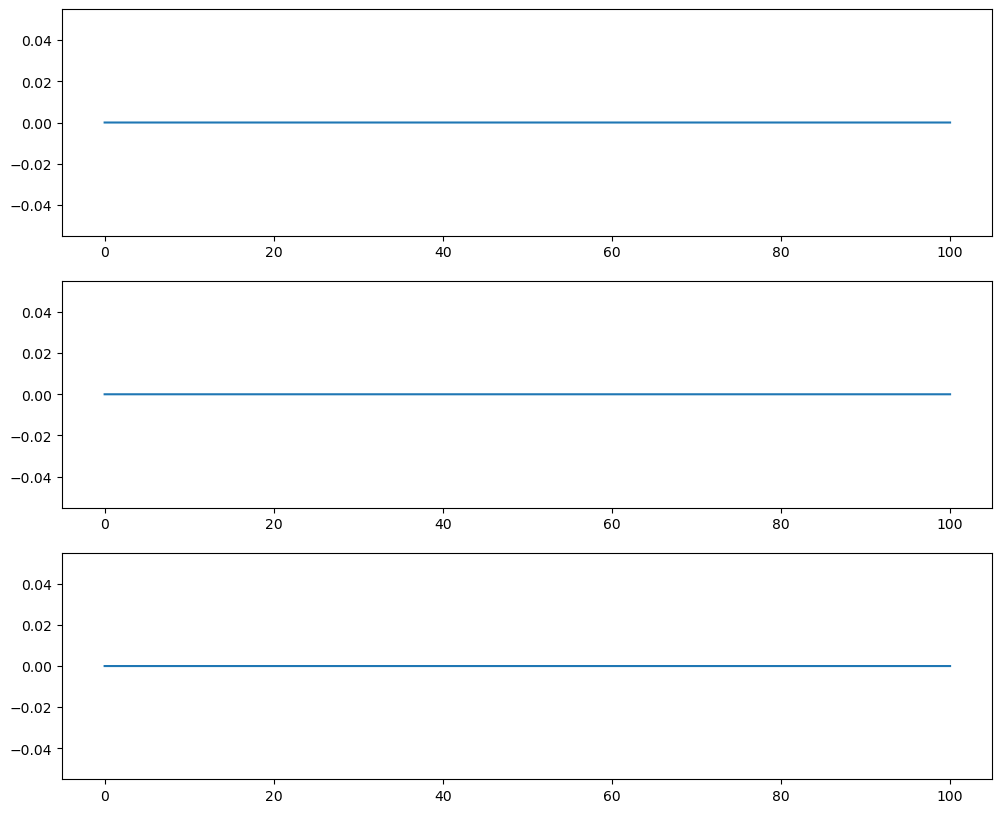

In [42]:
# Plot euler solver results (X1, X2 & X3 phases map)

## Define a delta for initial conditions

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(t, x1)
ax[1].plot(t, x2)
ax[2].plot(t, x3)

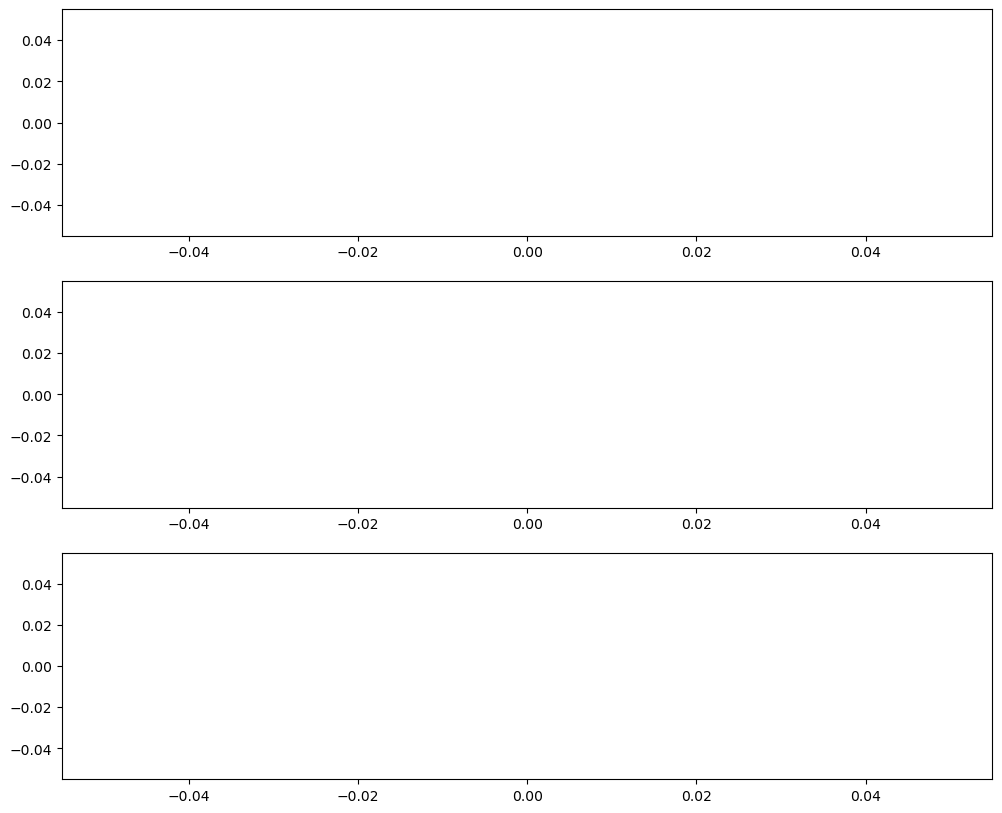

In [43]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(x1, x2)
ax[1].plot(x1, x3)
ax[2].plot(x2, x3)